In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely
import pandas as pd
from geodatasets import get_path
import ast
# import geopy.distance
from tqdm import tqdm

import matplotlib as mpl
from matplotlib.colors import ListedColormap
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import vis_utils as vu
import sample_locations as sl
import loadpaths
path_dict_pecl = loadpaths.loadpaths()
# import shapely
# from tqdm import tqdm, tqdm_notebook
# import ast, shutil

In [3]:
import ee, geemap
import api_keys

ee.Authenticate()
ee.Initialize(project=api_keys.GEE_API)
geemap.ee_initialize()

## Download random coords, get DW LC

In [ ]:
countries = gpd.read_file('/Users/tplas/data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')
df_points = pd.read_csv('/Users/tplas/data/dw_locations_2026-02-10-1308_year-2024_498-samples_50m.csv')
gdf_points = gpd.GeoDataFrame(df_points, geometry=gpd.points_from_xy(df_points.lon, df_points.lat), crs='EPSG:4326')
print(countries.crs)

EPSG:4326


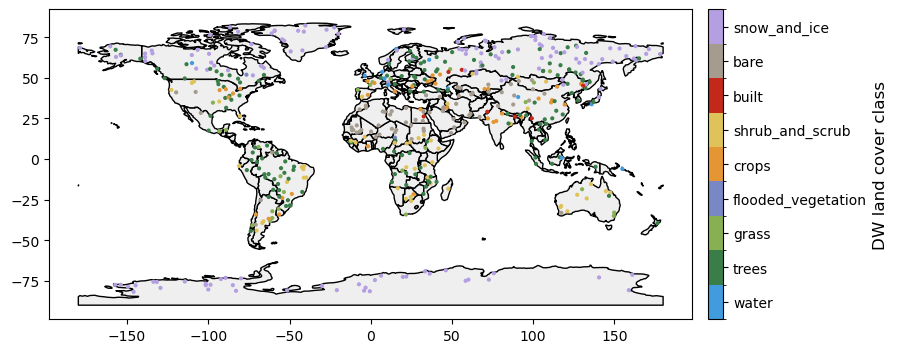

In [9]:
col_plot = 'label'

fig, ax = plt.subplots(figsize=(10, 6))
cmap_dict = du.create_mpl_cmap_dynamic_world()
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_points.plot(ax=ax, column=col_plot, markersize=4, 
                cmap=cmap_dict['all'] if col_plot == 'label' else cmap_dict['individual'][col_plot], 
                legend=False if col_plot == 'label' else True)

if col_plot == 'label':
    dw_classes = du.DW_CLASSES
    norm = mpl.colors.BoundaryNorm(
        boundaries=range(len(dw_classes) + 1),
        ncolors=len(dw_classes)
    )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_dict['all'])
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        ticks=range(len(dw_classes)),
        shrink=0.67,
        pad=0.02
    )

    cbar.set_ticks(np.arange(len(dw_classes)) + 0.5)
    cbar.set_ticklabels(dw_classes)
    cbar.set_label("DW land cover class", fontsize=12)



## Stratified sample via online GEE LC dataset
Works, but requires heavy GEE computation -> memory/budget constraints.

In [ ]:
prob_bands = [
    "water", "trees", "grass", "flooded_vegetation",
    "crops", "shrub_and_scrub", "built", "bare", "snow_and_ice"
]
label_band = 'label'
ex_collection = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
coords = (51, 4)
point = ee.Geometry.Point(coords)
aoi = point.buffer(2000).bounds()
assert ex_collection is not None

year = 2019
epsg_code = 32631  # UTM zone 31N
im_gee = ee.Image(ex_collection
                            .filterDate(ee.Date(f'{year}-01-01'), ee.Date(f'{year}-12-31'))
                            .select(label_band)  # get all probability bands
                            .mean()
)

points = im_gee.stratifiedSample(numPoints=5000,
                                 classBand=label_band,
                                 scale=10,
                                 projection=f'EPSG:{epsg_code}',
                                 seed=0,
                                 dropNulls=True,
                                 geometries=True,
                                 )

In [ ]:
def stratified_sample_dw_points(year=2024, centre_coords=(51.733075, -1.307027)[::-1], 
                                buffer_m=10000, num_points=5, scale=100, seed=0):

    # coords = (51.733075, -1.307027)[::-1]
    # coords = (46.675396, 6.931036)[::-1]  # Switzerland
    epsg_code = 32632  # UTM zone 32N
    point = ee.Geometry.Point(centre_coords)
    aoi = point.buffer(buffer_m).bounds()

    prob_bands = [
        "water", "trees", "grass", "flooded_vegetation",
        "crops", "shrub_and_scrub", "built", "bare", "snow_and_ice"
    ]

    dw_probs = (ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
                .filterBounds(aoi)
                .filterDate(f"{year}-01-01", f"{year}-12-31")
                .select(prob_bands)
                .mean() 
                .reproject(f'EPSG:{epsg_code}', scale=scale)  # reproject to 10m
                .clip(aoi)
                )

    # Get valid projection from any prob band
    proj = dw_probs.select(0).projection()

    label_img = (
        dw_probs
        .toArray()
        .arrayArgmax()
        .arrayProject([0])
        .arrayFlatten([['label']])
        .toInt()
        .reproject(proj)
    )


    points = label_img.stratifiedSample(
        numPoints = num_points,
        classBand = "label",
        scale = scale,
        seed = seed,
        dropNulls = True,
        geometries = True
    )

    coord_list = []
    label_list = []

    for feature in points.getInfo()['features']:
        coords = feature['geometry']['coordinates']
        label = feature['properties']['label']
        coord_list.append((coords[0], coords[1]))
        label_list.append(label)

    gdf_samples = gpd.GeoDataFrame({'label': label_list}, 
                                   geometry=gpd.points_from_xy([c[0] for c in coord_list], [c[1] for c in coord_list]))
    gdf_samples.crs = f'EPSG:{epsg_code}'
    return gdf_samples, points

# %timeit gdf_samples, points = stratified_sample_dw_points()